## Secuenciación de ADN y predicción del tipo de gen

- [Data Loading](#Data-Loading)
- [Data Exploration](#Data-Exploration)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Visualizations and Exploratory Analysis](#Visualizations-and-Exploratory-Analysis)
- [Predictor Construction](#Predictor-Construction)
- [Model Development](#Model-Development)
- [Conclusion and Future Work](#Conclusion-and-Future-Work)

In [15]:
# Instalar dependencias faltantes (se ejecuta en la celda de Jupyter si es necesario)
# Suprimir advertencias para que la salida sea mas limpia
import warnings
warnings.filterwarnings("ignore")

# Librerias basicas
import numpy as np
import pandas as pd

# Configuracion de matplotlib (backend sin interfaz grafica)
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Esta linea es para Jupyter / Kaggle Notebooks
%matplotlib inline

# Libreria para graficos estadisticos
import seaborn as sns

# Librerias de scikit-learn para construir y evaluar modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Estilo por defecto de los graficos de Seaborn
sns.set(style="whitegrid")

## Carga de datos

In [16]:
# Cargar los conjuntos de datos del directorio actual
train_df = pd.read_csv("dna-sequence-prediction/train.csv", encoding="ascii")
val_df   = pd.read_csv("dna-sequence-prediction/validation.csv", encoding="ascii")
test_df  = pd.read_csv("dna-sequence-prediction/test.csv", encoding="ascii")

# Mostrar las dimensiones de los conjuntos de datos
print("Forma de datos de entrenamiento:", train_df.shape)
print("Forma de datos de validación:", val_df.shape)
print("Forma de datos de prueba:", test_df.shape)

Forma de datos de entrenamiento: (22593, 7)
Forma de datos de validación: (4577, 7)
Forma de datos de prueba: (8326, 7)


## Exploración de datos

In [17]:
train_df.head()

,Unnamed: 0,NCBIGeneID,Symbol,Description,GeneType,GeneGroupMethod,NucleotideSequence
0,0,106481178,RNU4-21P,"RNA, U4 small nuclear 21, pseudogene",PSEUDO,NCBI Ortholog,<AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAG...
1,1,123477792,LOC123477792,Sharpr-MPRA regulatory region 12926,BIOLOGICAL_REGION,NCBI Ortholog,<CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCG...
2,2,113174975,LOC113174975,Sharpr-MPRA regulatory region 7591,BIOLOGICAL_REGION,NCBI Ortholog,<TTCCCAATTTTTCCTCTGCTTTTTAATTTTCTAGTTTCCTTTTTC...
3,3,116216107,LOC116216107,CRISPRi-validated cis-regulatory element chr10...,BIOLOGICAL_REGION,NCBI Ortholog,<CGCCCAGGCTGGAGTGCAGTGGCGCCATCTCGGCTCACTGCAGGC...
4,4,28502,IGHD2-21,immunoglobulin heavy diversity 2-21,OTHER,NCBI Ortholog,<AGCATATTGTGGTGGTGACTGCTATTCC>


In [18]:
# Muestra las primeras filas e información sobre los datos de entrenamiento para comprender su estructura.
train_df.info()
#print(train_df.info())

# Verificar la distribución de la variable objetivo (GeneType)
gene_type_counts = train_df['GeneType'].value_counts()
print('Distribución de GeneType en los datos de entrenamiento:')
print(gene_type_counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22593 entries, 0 to 22592
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          22593 non-null  int64 
 1   NCBIGeneID          22593 non-null  int64 
 2   Symbol              22593 non-null  object
 3   Description         22593 non-null  object
 4   GeneType            22593 non-null  object
 5   GeneGroupMethod     22593 non-null  object
 6   NucleotideSequence  22593 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.2+ MB
Distribución de GeneType en los datos de entrenamiento:
GeneType
PSEUDO               10220
BIOLOGICAL_REGION     6925
ncRNA                 2497
snoRNA                1148
PROTEIN_CODING         524
tRNA                   488
OTHER                  366
rRNA                   277
snRNA                  145
scRNA                    3
Name: count, dtype: int64


## Data Cleaning and Preprocessing

In [19]:
# Elimine la columna 'Unnamed: 0' ya que no es necesaria para el análisis
train_df.drop('Unnamed: 0', axis=1, inplace=True)
val_df.drop('Unnamed: 0', axis=1, inplace=True)
test_df.drop('Unnamed: 0', axis=1, inplace=True)

# Para mantener la consistencia, verifique si hay valores faltantes
print('Valores faltantes en los datos de entrenamiento:')
print(train_df.isnull().sum())

# Si hubiera valores faltantes en otros conjuntos de datos, se aplicaría una limpieza similar.
# En nuestro contexto, las columnas críticas son 'NucleotideSequence' y 'GeneType'.
# Aquí asumimos que 'NucleotideSequence' es una cadena que representa la secuencia de ADN, y 'GeneType' es nuestro objetivo de predicción.

Valores faltantes en los datos de entrenamiento:
NCBIGeneID            0
Symbol                0
Description           0
GeneType              0
GeneGroupMethod       0
NucleotideSequence    0
dtype: int64


In [21]:
train_df.head()
val_df.head()
test_df.head()

,NCBIGeneID,Symbol,Description,GeneType,GeneGroupMethod,NucleotideSequence
0,113748396,LOC113748396,Sharpr-MPRA regulatory region 1133,BIOLOGICAL_REGION,NCBI Ortholog,<CACTGCAGGCCGGAGCCCCCTGTTCCCCCGCATCCTCCCCGCCGT...
1,124900888,LOC124900888,U7 small nuclear RNA,PSEUDO,NCBI Ortholog,<AAAAGCAGCTCTTTCAGAATTTGTCTAGCAGGATTTCTAGTTTTC...
2,124174249,LOC124174249,Sharpr-MPRA regulatory region 5408,BIOLOGICAL_REGION,NCBI Ortholog,<TTGTGATTATGTTATTTTACATGGCAAAAGGGACTTTGCAGCGGT...
3,28685,TRAV8-1,T cell receptor alpha variable 8-1,OTHER,NCBI Ortholog,<ATGCTCCTGTTGCTCATACCAGTGCTGGGGATGATTTTTGCCCTG...
4,730061,RPL34P33,ribosomal protein L34 pseudogene 33,PSEUDO,NCBI Ortholog,<CTCTTCCGAGACATTGTCTGCAGGCACTCAGAATGGTCCAGCGTT...


## Visualizaciones y análisis exploratorio

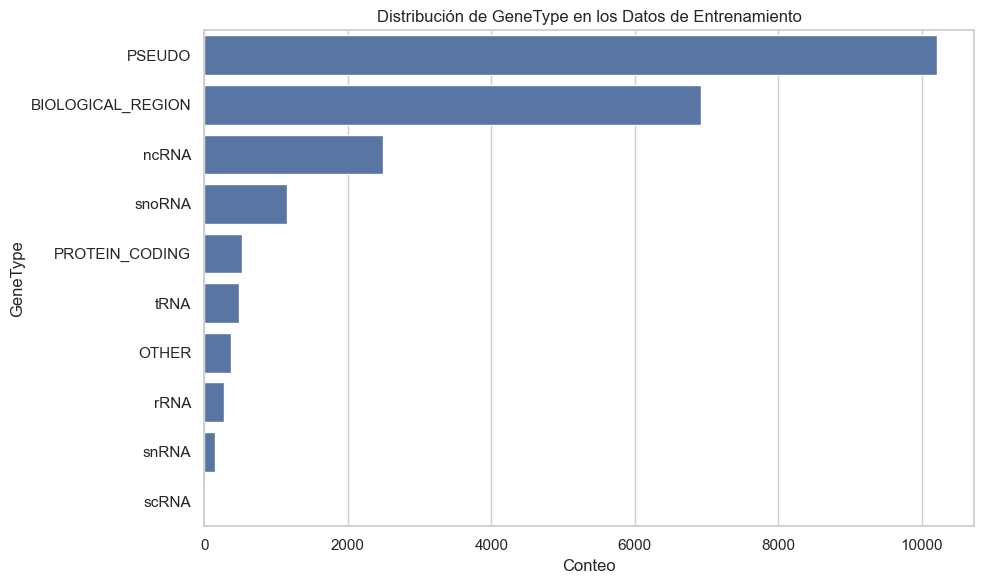

In [22]:
# Grafique la distribución de GeneType con un gráfico de conteo
plt.figure(figsize=(10,6))
sns.countplot(y='GeneType', data=train_df, order=train_df['GeneType'].value_counts().index)
plt.title('Distribución de GeneType en los Datos de Entrenamiento')
plt.xlabel('Conteo')
plt.ylabel('GeneType')
plt.tight_layout()
plt.show()

# Crear una nueva columna que capture la longitud de la secuencia de nucleótidos
train_df['seq_length'] = train_df['NucleotideSequence'].str.len()

In [23]:
train_df.head()

,NCBIGeneID,Symbol,Description,GeneType,GeneGroupMethod,NucleotideSequence,seq_length
0,106481178,RNU4-21P,"RNA, U4 small nuclear 21, pseudogene",PSEUDO,NCBI Ortholog,<AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAG...,128
1,123477792,LOC123477792,Sharpr-MPRA regulatory region 12926,BIOLOGICAL_REGION,NCBI Ortholog,<CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCG...,297
2,113174975,LOC113174975,Sharpr-MPRA regulatory region 7591,BIOLOGICAL_REGION,NCBI Ortholog,<TTCCCAATTTTTCCTCTGCTTTTTAATTTTCTAGTTTCCTTTTTC...,297
3,116216107,LOC116216107,CRISPRi-validated cis-regulatory element chr10...,BIOLOGICAL_REGION,NCBI Ortholog,<CGCCCAGGCTGGAGTGCAGTGGCGCCATCTCGGCTCACTGCAGGC...,278
4,28502,IGHD2-21,immunoglobulin heavy diversity 2-21,OTHER,NCBI Ortholog,<AGCATATTGTGGTGGTGACTGCTATTCC>,30


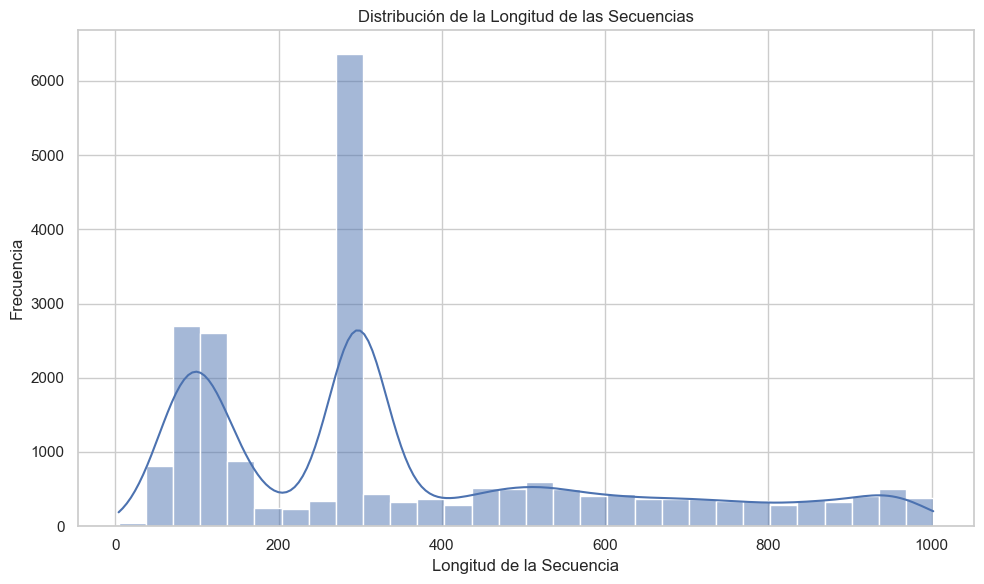

In [24]:


# Graficar un histograma de las longitudes de las secuencias
plt.figure(figsize=(10,6))
sns.histplot(data=train_df, x='seq_length', kde=True, bins=30)
plt.title('Distribución de la Longitud de las Secuencias')
plt.xlabel('Longitud de la Secuencia')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Nota: Solo hay dos columnas numéricas ('NCBIGeneID', 'seq_length').
# Por lo tanto, omitimos un mapa de calor de correlación, que es más útil cuando hay cuatro o más columnas numéricas presentes.

## Construcción de predictores

Precisión en la Validación: 0.7070133275071008


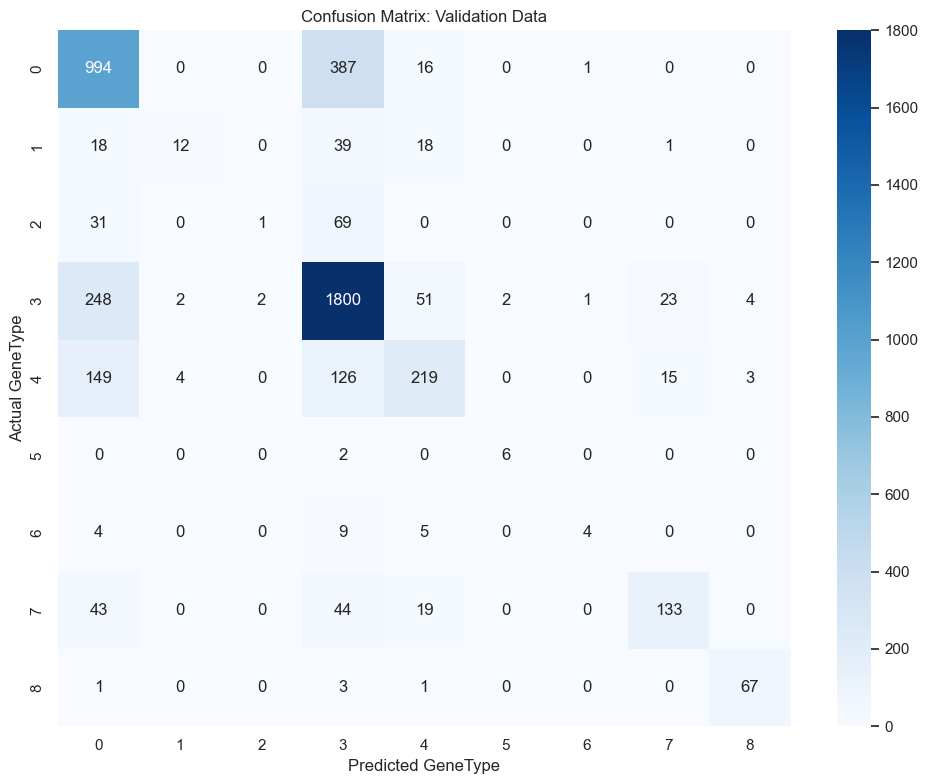

In [25]:
# Para nuestra tarea de predicción, predeciremos el 'GeneType' usando la "NucleotideSequence" como nuestra característica.
# Usamos un TfidfVectorizer para convertir las secuencias en características numéricas.
# Dada la naturaleza del ADN, se emplean n-gramas a nivel de caracteres (con n=3 para capturar características similares a codones).

pipeline = make_pipeline(
    TfidfVectorizer(analyzer='char', ngram_range=(3,3)),
    LogisticRegression(max_iter=1000)
)

# Ajuste el predictor a los datos de entrenamiento
pipeline.fit(train_df['NucleotideSequence'], train_df['GeneType'])

# Realizar predicciones en los datos de validación
val_predictions = pipeline.predict(val_df['NucleotideSequence'])

# Calcular la precisión de la predicción
accuracy = accuracy_score(val_df['GeneType'], val_predictions)
print('Precisión en la Validación:', accuracy)

# Generar y mostrar una matriz de confusión
cm = confusion_matrix(val_df['GeneType'], val_predictions)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Validation Data')
plt.xlabel('Predicted GeneType')
plt.ylabel('Actual GeneType')
plt.tight_layout()
plt.show() 

# El modelo construye un predictor base. El trabajo futuro puede involucrar la optimización de hiperparámetros,
# experimentar con métodos alternativos de extracción de características y probar otros modelos de clasificación.

# También tenga en cuenta: Si encuentra errores relacionados con la vectorización de texto o la convergencia del modelo, considere
# ajustar el parámetro 'max_iter' o preprocesar las secuencias de ADN más a fondo.

## Desarrollo de modelos

Distribución de clases binarias (datos de entrenamiento):
BinaryGeneType
OTHERS    12373
PSEUDO    10220
Name: count, dtype: int64

Precisión en la Validación (Clasificación Binaria): 0.7719

Informe de Clasificación:
              precision    recall  f1-score   support

      OTHERS       0.78      0.79      0.79      2444
      PSEUDO       0.76      0.75      0.75      2133

    accuracy                           0.77      4577
   macro avg       0.77      0.77      0.77      4577
weighted avg       0.77      0.77      0.77      4577



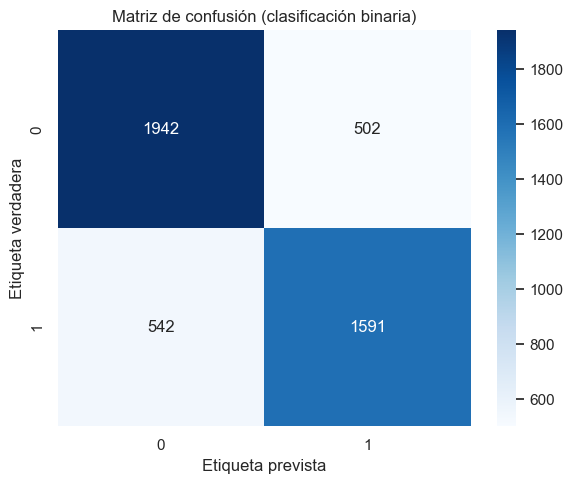


Predicciones de muestra en el conjunto de prueba:
                                            Sequence Predicted_BinaryGeneType
0  <CACTGCAGGCCGGAGCCCCCTGTTCCCCCGCATCCTCCCCGCCGT...                   OTHERS
1  <AAAAGCAGCTCTTTCAGAATTTGTCTAGCAGGATTTCTAGTTTTC...                   OTHERS
2  <TTGTGATTATGTTATTTTACATGGCAAAAGGGACTTTGCAGCGGT...                   OTHERS
3  <ATGCTCCTGTTGCTCATACCAGTGCTGGGGATGATTTTTGCCCTG...                   OTHERS
4  <CTCTTCCGAGACATTGTCTGCAGGCACTCAGAATGGTCCAGCGTT...                   OTHERS


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Paso 1: Crear etiquetas binarias ---
train_df['BinaryGeneType'] = train_df['GeneType'].apply(lambda x: 'PSEUDO' if x == 'PSEUDO' else 'OTHERS')
val_df['BinaryGeneType'] = val_df['GeneType'].apply(lambda x: 'PSEUDO' if x == 'PSEUDO' else 'OTHERS')
test_df['BinaryGeneType'] = test_df['GeneType'].apply(lambda x: 'PSEUDO' if x == 'PSEUDO' else 'OTHERS')

print("Distribución de clases binarias (datos de entrenamiento):")
print(train_df['BinaryGeneType'].value_counts())

# --- Paso 2: Definir el pipeline ---
binary_pipeline = make_pipeline(
    TfidfVectorizer(analyzer='char', ngram_range=(3,3)),
    LogisticRegression(max_iter=1000)
)

# --- Paso 3: Entrenar el modelo ---
binary_pipeline.fit(train_df['NucleotideSequence'], train_df['BinaryGeneType'])

# --- Paso 4: Evaluar en el conjunto de validación ---
val_pred = binary_pipeline.predict(val_df['NucleotideSequence'])
val_acc = accuracy_score(val_df['BinaryGeneType'], val_pred)
print(f"\nPrecisión en la Validación (Clasificación Binaria): {val_acc:.4f}")

# --- Paso 5: Informe detallado de rendimiento ---
print("\nInforme de Clasificación:")
print(classification_report(val_df['BinaryGeneType'], val_pred))

# --- Paso 6: Matriz de Confusión ---
cm = confusion_matrix(val_df['BinaryGeneType'], val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión (clasificación binaria)')
plt.xlabel('Etiqueta prevista')
plt.ylabel('Etiqueta verdadera')
plt.tight_layout()
plt.show()

# --- Paso 7: Opcional - Evaluar en el conjunto de prueba ---
test_pred = binary_pipeline.predict(test_df['NucleotideSequence'])
print("\nPredicciones de muestra en el conjunto de prueba:")
print(pd.DataFrame({
    'Sequence': test_df['NucleotideSequence'].head(5),
    'Predicted_BinaryGeneType': test_pred[:5]
}))

Distribución de clases binarias (datos de entrenamiento):
BinaryGeneType
PSEUDO               10220
BIOLOGICAL_REGION     6925
OTHERS                5448
Name: count, dtype: int64

Precisión en la Validación (Clasificación Binaria - PSEUDO/BIOLOGICAL_REGION vs OTHERS): 0.7090

Informe de Clasificación:
                   precision    recall  f1-score   support

BIOLOGICAL_REGION       0.65      0.73      0.69      1398
           OTHERS       0.65      0.63      0.64      1046
           PSEUDO       0.78      0.73      0.76      2133

         accuracy                           0.71      4577
        macro avg       0.70      0.70      0.70      4577
     weighted avg       0.71      0.71      0.71      4577



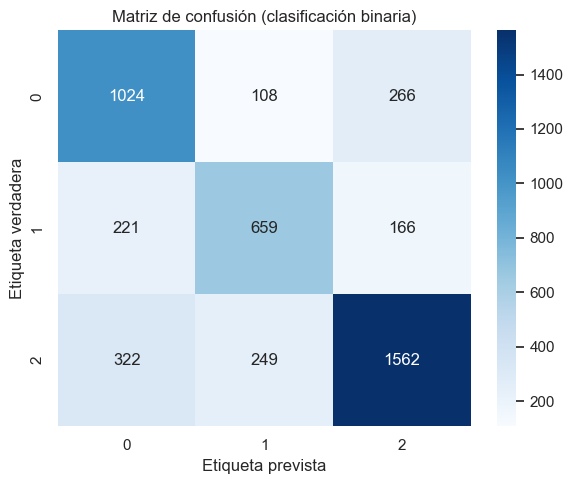


Predicciones de prueba de muestra:
                                            Sequence Predicted_BinaryGeneType
0  <CACTGCAGGCCGGAGCCCCCTGTTCCCCCGCATCCTCCCCGCCGT...                   OTHERS
1  <AAAAGCAGCTCTTTCAGAATTTGTCTAGCAGGATTTCTAGTTTTC...                   OTHERS
2  <TTGTGATTATGTTATTTTACATGGCAAAAGGGACTTTGCAGCGGT...                   OTHERS
3  <ATGCTCCTGTTGCTCATACCAGTGCTGGGGATGATTTTTGCCCTG...                   OTHERS
4  <CTCTTCCGAGACATTGTCTGCAGGCACTCAGAATGGTCCAGCGTT...                   OTHERS


In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Paso 1: Crear etiquetas binarias ---
def create_binary_class(df):
    return df['GeneType'].apply(lambda x: x if x in ['PSEUDO', 'BIOLOGICAL_REGION'] else 'OTHERS')

train_df['BinaryGeneType'] = create_binary_class(train_df)
val_df['BinaryGeneType'] = create_binary_class(val_df)
test_df['BinaryGeneType'] = create_binary_class(test_df)

print("Distribución de clases binarias (datos de entrenamiento):")
print(train_df['BinaryGeneType'].value_counts())

# --- Paso 2: Definir la tubería ---
binary_pipeline_2 = make_pipeline(
    TfidfVectorizer(analyzer='char', ngram_range=(3,3)),
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

# --- Paso 3: Entrenar el modelo ---
binary_pipeline_2.fit(train_df['NucleotideSequence'], train_df['BinaryGeneType'])

# --- Paso 4: Evaluar en el conjunto de validación ---
val_pred = binary_pipeline_2.predict(val_df['NucleotideSequence'])
val_acc = accuracy_score(val_df['BinaryGeneType'], val_pred)
print(f"\nPrecisión en la Validación (Clasificación Binaria - PSEUDO/BIOLOGICAL_REGION vs OTHERS): {val_acc:.4f}")

# --- Paso 5: Informe detallado de rendimiento ---
print("\nInforme de Clasificación:")
print(classification_report(val_df['BinaryGeneType'], val_pred))

# --- Paso 6: Matriz de Confusión ---
cm = confusion_matrix(val_df['BinaryGeneType'], val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión (clasificación binaria)')
plt.xlabel('Etiqueta prevista')
plt.ylabel('Etiqueta verdadera')
plt.tight_layout()
plt.show()

# --- Paso 7: Opcional - Evaluar en el conjunto de prueba ---
test_pred = binary_pipeline.predict(test_df['NucleotideSequence'])
print("\nPredicciones de prueba de muestra:")
print(pd.DataFrame({
    'Sequence': test_df['NucleotideSequence'].head(5),
    'Predicted_BinaryGeneType': test_pred[:5]
}))


Distribución de clases (datos de entrenamiento):
BinaryGeneType
PSEUDO               10220
BIOLOGICAL_REGION     6925
OTHERS                2951
ncRNA                 2497
Name: count, dtype: int64

Precisión en la Validación (PSEUDO/BIOLOGICAL_REGION/ncRNA vs OTHERS): 0.6675

Informe de Clasificación:
                   precision    recall  f1-score   support

BIOLOGICAL_REGION       0.67      0.69      0.68      1398
           OTHERS       0.47      0.51      0.49       530
           PSEUDO       0.79      0.71      0.75      2133
            ncRNA       0.48      0.57      0.52       516

         accuracy                           0.67      4577
        macro avg       0.60      0.62      0.61      4577
     weighted avg       0.68      0.67      0.67      4577



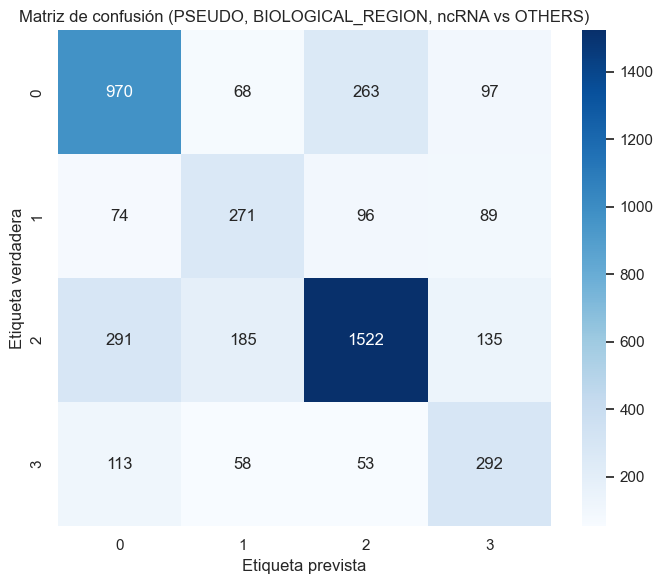


Predicciones de muestra en el conjunto de prueba:
                                            Sequence    Predicted_Label
0  <CACTGCAGGCCGGAGCCCCCTGTTCCCCCGCATCCTCCCCGCCGT...  BIOLOGICAL_REGION
1  <AAAAGCAGCTCTTTCAGAATTTGTCTAGCAGGATTTCTAGTTTTC...              ncRNA
2  <TTGTGATTATGTTATTTTACATGGCAAAAGGGACTTTGCAGCGGT...  BIOLOGICAL_REGION
3  <ATGCTCCTGTTGCTCATACCAGTGCTGGGGATGATTTTTGCCCTG...  BIOLOGICAL_REGION
4  <CTCTTCCGAGACATTGTCTGCAGGCACTCAGAATGGTCCAGCGTT...  BIOLOGICAL_REGION


In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Paso 1: Crear una agrupación binaria/multiclase ---
def create_binary_class(df):
    return df['GeneType'].apply(lambda x: x if x in ['PSEUDO', 'BIOLOGICAL_REGION', 'ncRNA'] else 'OTHERS')

train_df['BinaryGeneType'] = create_binary_class(train_df)
val_df['BinaryGeneType'] = create_binary_class(val_df)
test_df['BinaryGeneType'] = create_binary_class(test_df)

print("Distribución de clases (datos de entrenamiento):")
print(train_df['BinaryGeneType'].value_counts())

# --- Paso 2: Definir la tubería ---
multi_pipeline = make_pipeline(
    TfidfVectorizer(analyzer='char', ngram_range=(3,3)),
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

# --- Paso 3: Entrenar el modelo ---
multi_pipeline.fit(train_df['NucleotideSequence'], train_df['BinaryGeneType'])

# --- Paso 4: Evaluar en el conjunto de validación ---
val_pred = multi_pipeline.predict(val_df['NucleotideSequence'])
val_acc = accuracy_score(val_df['BinaryGeneType'], val_pred)
print(f"\nPrecisión en la Validación (PSEUDO/BIOLOGICAL_REGION/ncRNA vs OTHERS): {val_acc:.4f}")

# --- Paso 5: Informe detallado de rendimiento ---
print("\nInforme de Clasificación:")
print(classification_report(val_df['BinaryGeneType'], val_pred))

# --- Paso 6: Matriz de Confusión ---
cm = confusion_matrix(val_df['BinaryGeneType'], val_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión (PSEUDO, BIOLOGICAL_REGION, ncRNA vs OTHERS)')
plt.xlabel('Etiqueta prevista')
plt.ylabel('Etiqueta verdadera')
plt.tight_layout()
plt.show()

# --- Paso 7: Evaluar en el conjunto de prueba ---
test_pred = multi_pipeline.predict(test_df['NucleotideSequence'])
print("\nPredicciones de muestra en el conjunto de prueba:")
print(pd.DataFrame({
    'Sequence': test_df['NucleotideSequence'].head(5),
    'Predicted_Label': test_pred[:5]
}))


In [15]:
import joblib

# Guardar todos los modelos
joblib.dump(pipeline, "model_1_multiclass.pkl")  # Modelo 1 – Multiclase
joblib.dump(binary_pipeline, "model_2_pseudo_vs_others.pkl")  # Modelo 2 – PSEUDO vs OTROS
joblib.dump(binary_pipeline_2, "model_3_pseudo_bioregion_vs_others.pkl")  # Modelo 3 – PSEUDO, BIOLOGICAL_REGION vs OTROS
joblib.dump(multi_pipeline, "model_4_pseudo_bioregion_ncrna_vs_others.pkl")  # Modelo 4 – PSEUDO, BIOLOGICAL_REGION, ncRNA vs OTROS

print("✅ Todos los modelos se guardaron con éxito!")


✅ Todos los modelos se guardaron con éxito!


In [16]:
def predict_multiclass(sequence, model_path="model_1_multiclass.pkl"):
    model = joblib.load(model_path)
    pred = model.predict([sequence])[0]
    probs = model.predict_proba([sequence])[0]
    print("\n🧬 Modelo 1 - Clasificacion multiclase")
    print("Tipo de gen predicho:", pred)
    print("Probabilidades por clase:")
    for cls, p in zip(model.classes_, probs):
        print(f"  {cls}: {p:.4f}")
    return pred


def predict_pseudo_vs_others(sequence, model_path="model_2_pseudo_vs_others.pkl"):
    model = joblib.load(model_path)
    pred = model.predict([sequence])[0]
    probs = model.predict_proba([sequence])[0]
    print("\n🧬 Modelo 2 - Binario: PSEUDO vs OTHERS")
    print("Etiqueta predicha:", pred)
    print("Probabilidades:")
    for cls, p in zip(model.classes_, probs):
        print(f"  {cls}: {p:.4f}")
    return pred


def predict_pseudo_bioregion_vs_others(sequence, model_path="model_3_pseudo_bioregion_vs_others.pkl"):
    model = joblib.load(model_path)
    pred = model.predict([sequence])[0]
    probs = model.predict_proba([sequence])[0]
    print("\n🧬 Modelo 3 - Binario: PSEUDO, BIOLOGICAL_REGION vs OTHERS")
    print("Etiqueta predicha:", pred)
    print("Probabilidades:")
    for cls, p in zip(model.classes_, probs):
        print(f"  {cls}: {p:.4f}")
    return pred


def predict_pseudo_bioregion_ncrna_vs_others(sequence, model_path="model_4_pseudo_bioregion_ncrna_vs_others.pkl"):
    model = joblib.load(model_path)
    pred = model.predict([sequence])[0]
    probs = model.predict_proba([sequence])[0]
    print("\n🧬 Modelo 4 - Binario: PSEUDO, BIOLOGICAL_REGION, ncRNA vs OTHERS")
    print("Etiqueta predicha:", pred)
    print("Probabilidades:")
    for cls, p in zip(model.classes_, probs):
        print(f"  {cls}: {p:.4f}")
    return pred


In [17]:
example_seq = "<GGTTCGATGCCTCACAATTGCTGTGTTCTCCCTCCTGCAGAGCCCAGAGTTGATCTCTGCACCACTCTATCACTGCTGGGGGTGAGGAAATGGTGGAACCGGTGATTCAGGACTGTTTTTTCTCTCTTCTCAGTGCCTCTTTCAGTGATATGAAGTTAAAACCAGGTATTTTGAGTACTCACCTGATTTTTGGTTCTTATGAAAGTATTTTCTATGTAGATATTAATAGTTGTTCATCTGGTGTCCTTGCAGGATGGAAGATCAGTGGAGCCTTCTTTCTGCCATCTTGCTTTACCCTCACACCCAAGAATCAGAATGCAGAACTTTTAATCAGAAAAGCATTCAGAACTCAGGAAGGACATGGAAGACATCCTGGTTCTCCACGTTTAACATTGGACTGTTTCTTCAACTTAGGTGCATAGCACTGACACTAATCAGGGATTATCACCGATAATTTGACTTGGACTATGGAGTTCATTCAAATACTTTATCTAGACAATTTAAGTACTGGCTTATTTGTCATGAAAATCTGACAAAGTAATTTCTTGGTATTCAGTTGATTTTTACTCTGTTTGGGTTAGCAGTTTATAAACCAGTCAGTCTCTTCATTAAAGTTCTGGGAATTCTTACTCGTTCAAATGATATGATTCTAAAGTTCTCAAAAATCTGTATTCTAGAATTCTTCTCAGGACCTTTTCCCTCCTTTCATGAAACTCCTTAAAGATACAGTATTCTATAATTTTGCAAGCTTGTACAGTTTTCAGAAACTGCCTCAGAATTAAGCAATTTACAGTGGAAATGTTTTTAAATTGTCATAGACACAATTGACAAGAAAATTTTATTATTTACAGGCGTGAGCCACCACACCCAGCCTCTGAAGTTAATTTAATAAAATTTTATGAATAAATTTA>"

# Ejecutar predicciones
predict_multiclass(example_seq)
predict_pseudo_vs_others(example_seq)
predict_pseudo_bioregion_vs_others(example_seq)
predict_pseudo_bioregion_ncrna_vs_others(example_seq)


🧬 Modelo 1 - Clasificacion multiclase
Tipo de gen predicho: BIOLOGICAL_REGION
Probabilidades por clase:
  BIOLOGICAL_REGION: 0.5011
  OTHER: 0.0219
  PROTEIN_CODING: 0.0062
  PSEUDO: 0.3878
  ncRNA: 0.0559
  rRNA: 0.0002
  scRNA: 0.0001
  snRNA: 0.0059
  snoRNA: 0.0199
  tRNA: 0.0011

🧬 Modelo 2 - Binario: PSEUDO vs OTHERS
Etiqueta predicha: OTHERS
Probabilidades:
  OTHERS: 0.6144
  PSEUDO: 0.3856

🧬 Modelo 3 - Binario: PSEUDO, BIOLOGICAL_REGION vs OTHERS
Etiqueta predicha: BIOLOGICAL_REGION
Probabilidades:
  BIOLOGICAL_REGION: 0.5465
  OTHERS: 0.1669
  PSEUDO: 0.2866

🧬 Modelo 4 - Binario: PSEUDO, BIOLOGICAL_REGION, ncRNA vs OTHERS
Etiqueta predicha: BIOLOGICAL_REGION
Probabilidades:
  BIOLOGICAL_REGION: 0.4369
  OTHERS: 0.1739
  PSEUDO: 0.2321
  ncRNA: 0.1572


'BIOLOGICAL_REGION'

In [18]:
def predict_gene_type(model, sequence):
    """
    Predice el tipo de gen ('PSEUDO', 'BIOLOGICAL_REGION', 'ncRNA' u 'OTHERS')
    para una secuencia de nucleotidos de ADN usando un modelo de regresion logistica entrenado.
    """
    # Verificar que la entrada sea una cadena valida
    if not isinstance(sequence, str) or len(sequence.strip()) == 0:
        print("❌ Proporcione una secuencia de nucleotidos valida (cadena no vacia).")
        return

    # Predecir la clase
    prediction = model.predict([sequence])[0]
    
    # Obtener las probabilidades de prediccion (nivel de confianza)
    probabilities = model.predict_proba([sequence])[0]
    
    # Crear un diccionario clase -> probabilidad
    prob_dict = dict(zip(model.classes_, probabilities))
    
    # Mostrar el resultado
    print("🧬 Secuencia de ADN de entrada:")
    print(sequence[:100] + "..." if len(sequence) > 100 else sequence)  # truncar secuencias largas
    print("\n🔍 Tipo de gen predicho:", prediction)
    print("\n📊 Probabilidades de prediccion:")
    for cls, prob in prob_dict.items():
        print(f"  {cls}: {prob:.4f}")

    return prediction


# --- Ejemplo de uso ---
example_sequence = "<GGTTCGATGCCTCACAATTGCTGTGTTCTCCCTCCTGCAGAGCCCAGAGTTGATCTCTGCACCACTCTATCACTGCTGGGGGTGAGGAAATGGTGGAACCGGTGATTCAGGACTGTTTTTTCTCTCTTCTCAGTGCCTCTTTCAGTGATATGAAGTTAAAACCAGGTATTTTGAGTACTCACCTGATTTTTGGTTCTTATGAAAGTATTTTCTATGTAGATATTAATAGTTGTTCATCTGGTGTCCTTGCAGGATGGAAGATCAGTGGAGCCTTCTTTCTGCCATCTTGCTTTACCCTCACACCCAAGAATCAGAATGCAGAACTTTTAATCAGAAAAGCATTCAGAACTCAGGAAGGACATGGAAGACATCCTGGTTCTCCACGTTTAACATTGGACTGTTTCTTCAACTTAGGTGCATAGCACTGACACTAATCAGGGATTATCACCGATAATTTGACTTGGACTATGGAGTTCATTCAAATACTTTATCTAGACAATTTAAGTACTGGCTTATTTGTCATGAAAATCTGACAAAGTAATTTCTTGGTATTCAGTTGATTTTTACTCTGTTTGGGTTAGCAGTTTATAAACCAGTCAGTCTCTTCATTAAAGTTCTGGGAATTCTTACTCGTTCAAATGATATGATTCTAAAGTTCTCAAAAATCTGTATTCTAGAATTCTTCTCAGGACCTTTTCCCTCCTTTCATGAAACTCCTTAAAGATACAGTATTCTATAATTTTGCAAGCTTGTACAGTTTTCAGAAACTGCCTCAGAATTAAGCAATTTACAGTGGAAATGTTTTTAAATTGTCATAGACACAATTGACAAGAAAATTTTATTATTTACAGGCGTGAGCCACCACACCCAGCCTCTGAAGTTAATTTAATAAAATTTTATGAATAAATTTA>"

predicted_label = predict_gene_type(multi_pipeline, example_sequence)


🧬 Secuencia de ADN de entrada:
<GGTTCGATGCCTCACAATTGCTGTGTTCTCCCTCCTGCAGAGCCCAGAGTTGATCTCTGCACCACTCTATCACTGCTGGGGGTGAGGAAATGGTGGAAC...

🔍 Tipo de gen predicho: BIOLOGICAL_REGION

📊 Probabilidades de prediccion:
  BIOLOGICAL_REGION: 0.4369
  OTHERS: 0.1739
  PSEUDO: 0.2321
  ncRNA: 0.1572


## Conclusión

En este proyecto exploramos con exito la tarea de predecir tipos de genes a partir de secuencias de ADN utilizando varios modelos de aprendizaje automatico. Al experimentar con distintas estrategias de clasificacion —desde modelos multiclase hasta modelos binarios dirigidos— obtuvimos informacion valiosa sobre como los patrones de secuencia se correlacionan con las categorias biologicas de los genes.

Nuestros resultados ponen de manifiesto que incluso los modelos de ML tradicionales, cuando se entrenan y preprocesan adecuadamente, pueden descubrir relaciones significativas dentro de los datos genomicos. Estos resultados sirven como base para investigaciones y aplicaciones mas avanzadas en bioinformatica.

🔮 Trabajo futuro

Aunque los modelos actuales muestran un buen rendimiento, existe un potencial significativo para mejorar mediante:

Arquitecturas de aprendizaje profundo (por ejemplo, CNN, RNN o Transformers) para una mejor comprension de las secuencias.

Ingenieria de caracteristicas usando embeddings de k-mers o motivos de secuencia.

Conjuntos de datos mas grandes para capturar una mayor diversidad biologica.

Integracion con metadatos biologicos para lograr predicciones mas conscientes del contexto.

Al extender este trabajo, podemos acercarnos a la construccion de sistemas de IA robustos que ayuden en la anotacion genomica, la deteccion de mutaciones y la prediccion de enfermedades.